In [1]:
import arff
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

## Config

In [2]:
# Global Configuration
SEED_BASE = 42  # Base seed for reproducibility, will be incremented for each experiment
DATA_PATH = "data/adult.arff"
TARGET_COLUMN = "income"
TEST_SIZE = 0.2
K_FOLDS_DETECTION = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed set to {seed}")


set_seed(SEED_BASE)

Using device: cuda
Seed set to 42


## Data Loading and Preprocessing

In [3]:
def load_arff_to_dataframe(file_path, target_column):
    with open(file_path, 'r') as f:
        arff_data = arff.load(f)

    attributes = arff_data['attributes']
    column_names = [attr[0] for attr in attributes]
    data = pd.DataFrame(arff_data['data'], columns=column_names)

    numerical_features = []
    categorical_features = []
    feature_names_original = []

    for name, type_info in attributes:
        if name == target_column:
            continue
        feature_names_original.append(name)

        if isinstance(type_info, str) and type_info == 'NUMERIC':
            numerical_features.append(name)
            data[name] = pd.to_numeric(data[name], errors='coerce')
        else:  # Nominal/Categorical
            categorical_features.append(name)
            data[name] = data[name].astype('category')

    print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
    print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

    # Handle Missing Values (Mode imputation for categorical, mean for numerical)
    for col in numerical_features:
        if data[col].isnull().any():
            print(f"Missing values in numerical feature '{col}', imputing with mean.")
            data[col] = data[col].fillna(data[col].mean())
    for col in categorical_features:
        if data[col].isnull().any():
            print(f"Missing values in categorical feature '{col}', imputing with mode.")
            data[col] = data[col].fillna(data[col].mode()[0])

    # Target variable encoding
    y_raw = data[TARGET_COLUMN]
    le_target = LabelEncoder()
    y = le_target.fit_transform(y_raw)
    print(f"Target variable '{TARGET_COLUMN}' encoded. Classes: {le_target.classes_}, Encoded: {np.unique(y)}")

    X = data.drop(TARGET_COLUMN, axis=1)

    return X, y, numerical_features, categorical_features, le_target.classes_


# Load the data
X_raw_full, y_full, NUMERICAL_FEATURES, CATEGORICAL_FEATURES, target_class_names = load_arff_to_dataframe(DATA_PATH,
                                                                                                          TARGET_COLUMN)
print(f"Shape of X_raw_full: {X_raw_full.shape}, Shape of y_full: {y_full.shape}")

Numerical features (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Missing values in categorical feature 'workclass', imputing with mode.
Missing values in categorical feature 'occupation', imputing with mode.
Missing values in categorical feature 'native-country', imputing with mode.
Target variable 'income' encoded. Classes: ['<=50K' '>50K'], Encoded: [0 1]
Shape of X_raw_full: (32561, 14), Shape of y_full: (32561,)


## GAN

### Implementation

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, n_categories_per_feature, hidden_dim1, hidden_dim2):
        super().__init__()

        self.n_categories_per_feature = n_categories_per_feature

        # Shared trunk
        self.trunk = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm1d(hidden_dim1),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm1d(hidden_dim2)
        )

        # Num Head
        self.num_out = len(NUMERICAL_FEATURES)
        self.num_head = nn.Sequential(
            nn.Linear(hidden_dim2, self.num_out),
            nn.Sigmoid()
        )

        # Categorical Head
        self.cat_out_dim = sum(self.n_categories_per_feature)
        self.cat_logits_head = nn.Linear(hidden_dim2, self.cat_out_dim)

    def forward(self, z):
        h = self.trunk(z)
        num_part = self.num_head(h)

        # Apply Gumbel-Softmax
        cat_logits_all = self.cat_logits_head(h)
        cat_parts_gumbel = []
        current_idx = 0
        for num_categories_for_this_feature in self.n_categories_per_feature:
            logits_this_feature = cat_logits_all[:, current_idx: current_idx + num_categories_for_this_feature]
            gumbel_output_this_feature = F.gumbel_softmax(logits_this_feature, tau=1.0, hard=True, dim=-1)
            cat_parts_gumbel.append(gumbel_output_this_feature)
            current_idx += num_categories_for_this_feature
        cat_part = torch.cat(cat_parts_gumbel, dim=1)

        return torch.cat([num_part, cat_part], dim=1)


class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),  # Dropout for regularization

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim2, 1),
            nn.Sigmoid()  # Outputs a probability (real vs. fake)
        )

    def forward(self, x):
        return self.model(x)

### Training

In [5]:
def train_gan(generator, discriminator, data_loader, latent_dim, epochs, lr_g, lr_d, beta1, beta2, device):
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))

    criterion = nn.BCELoss()  # Binary Cross Entropy Loss

    g_losses_epoch = []
    d_losses_epoch = []

    best_g_loss = float('inf')
    for epoch in tqdm(range(epochs), desc="GAN Training Epochs"):
        generator.train()
        discriminator.train()

        g_losses_batch = []
        d_losses_batch = []

        for i, (real_samples_batch,) in enumerate(data_loader):
            real_samples_batch = real_samples_batch.to(device)
            batch_size = real_samples_batch.size(0)

            # Labels
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            #  Train Discriminator
            optimizer_D.zero_grad()
            # Loss for real images
            real_output = discriminator(real_samples_batch)
            d_loss_real = criterion(real_output, real_labels)
            # Loss for fake images
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_samples = generator(z)
            fake_output = discriminator(fake_samples.detach())
            d_loss_fake = criterion(fake_output, fake_labels)
            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()
            d_losses_batch.append(d_loss.item())

            #  Train Generator
            optimizer_G.zero_grad()
            # Generate fake images
            z_g = torch.randn(batch_size, latent_dim, device=device)
            fake_samples_g = generator(z_g)
            output_g = discriminator(fake_samples_g)  # We want D to think these are real
            # Generator loss
            g_loss = criterion(output_g, real_labels)  # G tries to make D output 1 for fakes
            g_loss.backward()
            optimizer_G.step()
            g_losses_batch.append(g_loss.item())

        avg_g_loss = np.mean(g_losses_batch) if g_losses_batch else 0
        avg_d_loss = np.mean(d_losses_batch) if d_losses_batch else 0

        g_losses_epoch.append(avg_g_loss)
        d_losses_epoch.append(avg_d_loss)

        print(f"GAN Epoch [{epoch + 1}/{epochs}], D Loss: {avg_d_loss:.4f}, G Loss: {avg_g_loss:.4f}")

        # Save the best model based on generator loss
        if avg_g_loss < best_g_loss and epoch > 10:
            best_g_loss = avg_g_loss
            torch.save(generator.state_dict(), 'best_gan_g_model.pt')
            torch.save(discriminator.state_dict(), 'best_gan_d_model.pt')
            print(f"🎉 Epoch {epoch + 1}: New best G loss: {avg_g_loss:.4f}.")

    return g_losses_epoch, d_losses_epoch

### Visualization

In [6]:
# Plotting Losses helper
def plot_losses(g_losses, d_losses, model_name):
    plt.figure(figsize=(10, 5))
    plt.plot(g_losses, label=f'{model_name} Generator Loss')
    plt.plot(d_losses, label=f'{model_name} Discriminator Loss')
    plt.title(f'{model_name} Training Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

### Training GAN


--- GAN Training---


GAN Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

GAN Epoch [1/100], D Loss: 1.3588, G Loss: 0.6911
GAN Epoch [2/100], D Loss: 1.2916, G Loss: 0.7321
GAN Epoch [3/100], D Loss: 1.2031, G Loss: 0.7907
GAN Epoch [4/100], D Loss: 1.1198, G Loss: 0.8489
GAN Epoch [5/100], D Loss: 1.0501, G Loss: 0.9148
GAN Epoch [6/100], D Loss: 0.9927, G Loss: 0.9822
GAN Epoch [7/100], D Loss: 0.9624, G Loss: 1.0361
GAN Epoch [8/100], D Loss: 0.9556, G Loss: 1.0662
GAN Epoch [9/100], D Loss: 0.9650, G Loss: 1.0915
GAN Epoch [10/100], D Loss: 0.9914, G Loss: 1.0913
GAN Epoch [11/100], D Loss: 1.0111, G Loss: 1.1004
GAN Epoch [12/100], D Loss: 1.0302, G Loss: 1.0956
🎉 Epoch 12: New best G loss: 1.0956.
GAN Epoch [13/100], D Loss: 1.0524, G Loss: 1.1051
GAN Epoch [14/100], D Loss: 1.0691, G Loss: 1.1112
GAN Epoch [15/100], D Loss: 1.0877, G Loss: 1.1244
GAN Epoch [16/100], D Loss: 1.1138, G Loss: 1.1181
GAN Epoch [17/100], D Loss: 1.1379, G Loss: 1.1163
GAN Epoch [18/100], D Loss: 1.1646, G Loss: 1.1206
GAN Epoch [19/100], D Loss: 1.1862, G Loss: 1.1071
GAN

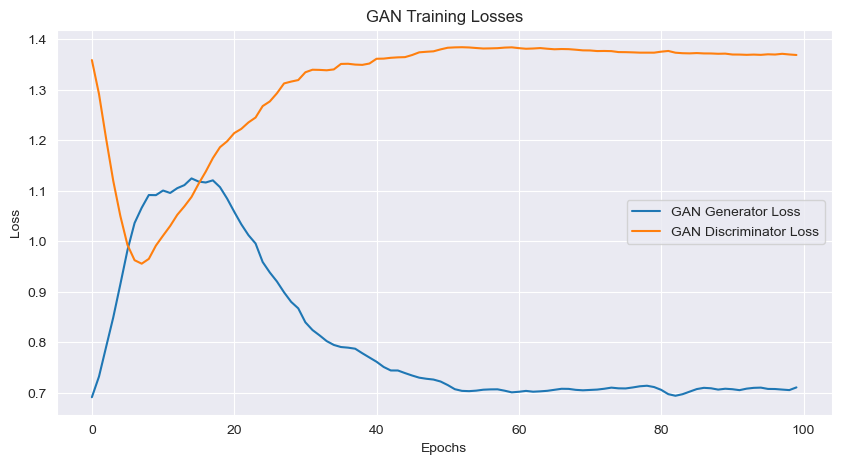

C:\Users\forgedRice\AppData\Local\Temp\ipykernel_72104\1663799130.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gan_generator.load_state_dict(torch.load('best_gan_g_m

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=105, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [7]:
# GAN Training Hyperparameters
EPOCHS = 100
BATCH_SIZE = 128
LR_G = 0.00002
LR_D = 0.00001
LATENT_DIM = 64
BETA1 = 0.5
BETA2 = 0.999

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw_full, y_full, test_size=TEST_SIZE,
                                                            random_state=SEED_BASE, stratify=y_full)

# Initialize and fit preprocessor (only on training data)
preprocessor_exp = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None), CATEGORICAL_FEATURES)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor_exp.fit_transform(X_train_raw)
X_test_processed = preprocessor_exp.transform(X_test_raw)

ohe_categories_ = preprocessor_exp.named_transformers_['cat'].categories_
n_categories_per_feature_list = [len(cats) for cats in ohe_categories_]

current_ohe_names = preprocessor_exp.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
current_processed_feature_names = NUMERICAL_FEATURES + list(current_ohe_names)
current_input_dim = X_train_processed.shape[1]

X_train_tensor = torch.FloatTensor(X_train_processed).to(DEVICE)

# GAN Training
print(f"\n--- GAN Training---")
gan_generator = Generator(LATENT_DIM, n_categories_per_feature=n_categories_per_feature_list, hidden_dim1=256,
                          hidden_dim2=512).to(DEVICE)
gan_discriminator = Discriminator(current_input_dim, hidden_dim1=256, hidden_dim2=128).to(DEVICE)

gan_train_dataset = TensorDataset(X_train_tensor)
gan_train_loader = DataLoader(gan_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

gan_g_losses, gan_d_losses = train_gan(gan_generator, gan_discriminator, gan_train_loader, LATENT_DIM, EPOCHS, LR_G,
                                       LR_D, BETA1, BETA2, DEVICE)
plot_losses(gan_g_losses, gan_d_losses, "GAN")

# Load best model
gan_generator.load_state_dict(torch.load('best_gan_g_model.pt', map_location=DEVICE))
gan_discriminator.load_state_dict(torch.load('best_gan_d_model.pt', map_location=DEVICE))
gan_generator.to(DEVICE)
gan_discriminator.to(DEVICE)

### Evaluation

In [8]:
def generate_synthetic_data_gan(generator, n_samples, latent_dim, device):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim).to(device)
        synthetic_data = generator(z).cpu().numpy()
    generator.train()
    return synthetic_data


def calculate_detection_metric(real_data, synthetic_data, n_splits, random_state_fold):
    n_real = real_data.shape[0]
    n_synthetic = synthetic_data.shape[0]

    # Labels: 0 for real, 1 for synthetic
    y_real_labels = np.zeros(n_real)
    y_synthetic_labels = np.ones(n_synthetic)

    aucs_rf = []
    aucs_lr = []

    # KFold for splitting indices of real and synthetic data separately
    kf_real = KFold(n_splits=n_splits, shuffle=True, random_state=random_state_fold)
    kf_synth = KFold(n_splits=n_splits, shuffle=True, random_state=random_state_fold + 1)  # Ensure different shuffles

    real_folds_indices = list(kf_real.split(real_data))
    synth_folds_indices = list(kf_synth.split(synthetic_data))

    for i in range(n_splits):
        test_idx_real = real_folds_indices[i][1]
        train_idx_real_list = [real_folds_indices[j][1] for j in range(n_splits) if j != i]
        train_idx_real = np.concatenate(train_idx_real_list)

        test_idx_synth = synth_folds_indices[i][1]
        train_idx_synth_list = [synth_folds_indices[j][1] for j in range(n_splits) if j != i]
        train_idx_synth = np.concatenate(train_idx_synth_list)

        X_train_fold = np.vstack((real_data[train_idx_real], synthetic_data[train_idx_synth]))
        y_train_fold = np.concatenate((y_real_labels[train_idx_real], y_synthetic_labels[train_idx_synth]))
        X_test_fold = np.vstack((real_data[test_idx_real], synthetic_data[test_idx_synth]))
        y_test_fold = np.concatenate((y_real_labels[test_idx_real], y_synthetic_labels[test_idx_synth]))

        # Shuffle combined fold data to mix real/synthetic samples
        perm_train = np.random.permutation(len(X_train_fold))
        X_train_fold, y_train_fold = X_train_fold[perm_train], y_train_fold[perm_train]
        perm_test = np.random.permutation(len(X_test_fold))
        X_test_fold, y_test_fold = X_test_fold[perm_test], y_test_fold[perm_test]

        rf_detector = RandomForestClassifier(random_state=random_state_fold, n_estimators=10, n_jobs=-1)
        lr_detector = LogisticRegression(random_state=random_state_fold)

        rf_detector.fit(X_train_fold, y_train_fold)
        lr_detector.fit(X_train_fold, y_train_fold)

        preds_proba_rf = rf_detector.predict_proba(X_test_fold)[:, 1]  # Prob of being synthetic
        preds_proba_lr = lr_detector.predict_proba(X_test_fold)[:, 1]

        auc_rf = roc_auc_score(y_test_fold, preds_proba_rf)
        auc_lr = roc_auc_score(y_test_fold, preds_proba_lr)

        aucs_rf.append(auc_rf)
        aucs_lr.append(auc_lr)

    return np.mean(aucs_rf), np.mean(aucs_lr)


def calculate_efficacy_metric(X_train_real_proc, y_train_real, X_test_real_proc, y_test_real, X_synthetic_proc,
                              y_synthetic_labels, random_state_rf):
    rf_real_model = RandomForestClassifier(random_state=random_state_rf, n_estimators=10, n_jobs=-1)
    rf_real_model.fit(X_train_real_proc, y_train_real)
    preds_proba_real = rf_real_model.predict_proba(X_test_real_proc)[:, 1]  # Prob of class 1
    auc_real = roc_auc_score(y_test_real, preds_proba_real)

    rf_synthetic_model = RandomForestClassifier(random_state=random_state_rf, n_estimators=10, n_jobs=-1)
    rf_synthetic_model.fit(X_synthetic_proc, y_synthetic_labels)
    preds_proba_synthetic = rf_synthetic_model.predict_proba(X_test_real_proc)[:, 1]
    auc_synthetic = roc_auc_score(y_test_real, preds_proba_synthetic)

    efficacy = auc_synthetic / auc_real if auc_real != 0 else 0
    return auc_real, auc_synthetic, efficacy

In [9]:
n_synthetic_samples = X_train_processed.shape[0]  # Equal in size to training set
synthetic_data_gan = generate_synthetic_data_gan(gan_generator, n_synthetic_samples, LATENT_DIM, DEVICE)
print(f"Generated {synthetic_data_gan.shape[0]} GAN samples.")

# Detection Metric
det_auc_rf_gan, det_auc_lr_gan = calculate_detection_metric(X_train_processed, synthetic_data_gan, K_FOLDS_DETECTION,
                                                            SEED_BASE)
print(f"GAN Detection Metric Random Forest (Avg AUC): {det_auc_rf_gan:.4f} (Lower is better)")
print(f"GAN Detection Metric Logistic Regression (Avg AUC): {det_auc_lr_gan:.4f} (Lower is better)")

# Efficacy Metric
print("\nCalculating Efficacy Metric...")
label_predictor_for_gan = RandomForestClassifier(random_state=SEED_BASE, n_estimators=100, n_jobs=-1)
label_predictor_for_gan.fit(X_train_processed, y_train)
synthetic_labels_gan_for_efficacy = label_predictor_for_gan.predict(synthetic_data_gan)

auc_real_gan, auc_synth_gan, eff_gan = calculate_efficacy_metric(X_train_processed, y_train, X_test_processed, y_test,
                                                                 synthetic_data_gan, synthetic_labels_gan_for_efficacy,
                                                                 SEED_BASE)
print(
    f"GAN Efficacy: AUC_real={auc_real_gan:.4f}, AUC_synthetic_GAN={auc_synth_gan:.4f}, Efficacy_GAN={eff_gan:.4f} (Higher is better)")

Generated 26048 GAN samples.
GAN Detection Metric Random Forest (Avg AUC): 1.0000 (Lower is better)
GAN Detection Metric Logistic Regression (Avg AUC): 0.6209 (Lower is better)

Calculating Efficacy Metric...
GAN Efficacy: AUC_real=0.8862, AUC_synthetic_GAN=0.8609, Efficacy_GAN=0.9715 (Higher is better)


## cGAN

### Implementation

In [10]:
class CGenerator(nn.Module):
    def __init__(self, latent_dim, n_categories_per_feature, hidden_dim1, hidden_dim2):
        super().__init__()
        self.n_categories_per_feature = n_categories_per_feature

        # Input to trunk is noise + one-hot label
        self.trunk = nn.Sequential(
            nn.Linear(latent_dim + len(target_class_names), hidden_dim1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm1d(hidden_dim1),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm1d(hidden_dim2)
        )
        self.num_head = nn.Sequential(
            nn.Linear(hidden_dim2, len(NUMERICAL_FEATURES)),
            nn.Sigmoid()
        )
        self.cat_out_dim = sum(self.n_categories_per_feature)
        self.cat_logits_head = nn.Linear(hidden_dim2, self.cat_out_dim)

    def forward(self, z, c_one_hot):  # c_one_hot is the one-hot encoded class label
        zc = torch.cat([z, c_one_hot], dim=1)
        h = self.trunk(zc)
        num_part = self.num_head(h)

        cat_logits_all = self.cat_logits_head(h)
        cat_parts_gumbel = []
        current_idx = 0
        for num_categories_for_this_feature in self.n_categories_per_feature:
            logits_this_feature = cat_logits_all[:, current_idx: current_idx + num_categories_for_this_feature]
            gumbel_output_this_feature = F.gumbel_softmax(
                logits_this_feature, tau=1.0, hard=True, dim=-1
            )
            cat_parts_gumbel.append(gumbel_output_this_feature)
            current_idx += num_categories_for_this_feature
        cat_part = torch.cat(cat_parts_gumbel, dim=1) if cat_parts_gumbel else torch.empty(z.size(0), 0).to(z.device)
        return torch.cat([num_part, cat_part], dim=1)


class CDiscriminator(nn.Module):
    def __init__(self, data_dim, hidden_dim1, hidden_dim2):
        super().__init__()
        # Input to model is data_sample + one-hot label
        self.model = nn.Sequential(
            nn.Linear(data_dim + len(target_class_names), hidden_dim1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim2, 1),
            nn.Sigmoid()
        )

    def forward(self, x, c_one_hot):  # c_one_hot is the one-hot encoded class label
        xc = torch.cat([x, c_one_hot], dim=1)
        return self.model(xc)

### Training

In [11]:
def train_cgan(generator, discriminator, data_loader, latent_dim, epochs, lr_g, lr_d, beta1, beta2, device):
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))

    criterion = nn.BCELoss()  # Binary Cross Entropy Loss

    g_losses_epoch = []
    d_losses_epoch = []

    best_g_loss = float('inf')
    for epoch in tqdm(range(epochs), desc="cGAN Training Epochs"):
        generator.train()
        discriminator.train()

        g_losses_batch = []
        d_losses_batch = []

        for real_samples_batch, labels_batch_idx in data_loader:
            real_samples_batch = real_samples_batch.to(device)
            labels_batch_idx = labels_batch_idx.to(device)
            batch_size = real_samples_batch.size(0)

            labels_one_hot = F.one_hot(labels_batch_idx, num_classes=len(target_class_names)).float().to(device)

            real_lab = torch.ones(batch_size, 1, device=device)
            fake_lab = torch.zeros(batch_size, 1, device=device)

            # Train Discriminator
            optimizer_D.zero_grad()
            # Real samples
            real_output = discriminator(real_samples_batch, labels_one_hot)  # Condition with true labels
            d_loss_real = criterion(real_output, real_lab)
            # Fake samples
            z = torch.randn(batch_size, latent_dim, device=device)
            gen_labels_one_hot = labels_one_hot
            fake_samples = generator(z, gen_labels_one_hot)
            fake_output = discriminator(fake_samples.detach(), gen_labels_one_hot)
            d_loss_fake = criterion(fake_output, fake_lab)
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()
            d_losses_batch.append(d_loss.item())

            # Train Generator
            optimizer_G.zero_grad()
            z_g = torch.randn(batch_size, latent_dim, device=device)
            fake_samples_g = generator(z_g, gen_labels_one_hot)
            output_g = discriminator(fake_samples_g, gen_labels_one_hot)
            g_loss = criterion(output_g, real_lab)  # G tries to make D output 1 for fakes
            g_loss.backward()
            optimizer_G.step()
            g_losses_batch.append(g_loss.item())

        avg_g_loss = np.mean(g_losses_batch)
        avg_d_loss = np.mean(d_losses_batch)

        g_losses_epoch.append(avg_g_loss)
        d_losses_epoch.append(avg_d_loss)

        print(f"cGAN Epoch [{epoch + 1}/{epochs}], D Loss: {avg_d_loss:.4f}, G Loss: {avg_g_loss:.4f}")

        # Save the best model based on generator loss
        if avg_g_loss < best_g_loss and epoch > 10:
            best_g_loss = avg_g_loss
            torch.save(generator.state_dict(), 'best_cgan_g_model.pt')
            torch.save(discriminator.state_dict(), 'best_cgan_d_model.pt')
            print(f"🎉 Epoch {epoch + 1}: New best G loss: {avg_g_loss:.4f}.")

    return g_losses_epoch, d_losses_epoch

### Training cGAN


--- cGAN Training---


cGAN Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

cGAN Epoch [1/100], D Loss: 1.3769, G Loss: 0.6869
cGAN Epoch [2/100], D Loss: 1.3157, G Loss: 0.7150
cGAN Epoch [3/100], D Loss: 1.2339, G Loss: 0.7553
cGAN Epoch [4/100], D Loss: 1.1542, G Loss: 0.7993
cGAN Epoch [5/100], D Loss: 1.1083, G Loss: 0.8384
cGAN Epoch [6/100], D Loss: 1.0669, G Loss: 0.8963
cGAN Epoch [7/100], D Loss: 1.0531, G Loss: 0.9325
cGAN Epoch [8/100], D Loss: 1.0535, G Loss: 0.9573
cGAN Epoch [9/100], D Loss: 1.0731, G Loss: 0.9792
cGAN Epoch [10/100], D Loss: 1.0980, G Loss: 0.9764
cGAN Epoch [11/100], D Loss: 1.1336, G Loss: 0.9504
cGAN Epoch [12/100], D Loss: 1.1592, G Loss: 0.9420
🎉 Epoch 12: New best G loss: 0.9420.
cGAN Epoch [13/100], D Loss: 1.1600, G Loss: 0.9485
cGAN Epoch [14/100], D Loss: 1.1726, G Loss: 0.9468
cGAN Epoch [15/100], D Loss: 1.2158, G Loss: 0.9339
🎉 Epoch 15: New best G loss: 0.9339.
cGAN Epoch [16/100], D Loss: 1.2397, G Loss: 0.9214
🎉 Epoch 16: New best G loss: 0.9214.
cGAN Epoch [17/100], D Loss: 1.2537, G Loss: 0.9220
cGAN Epoch [18

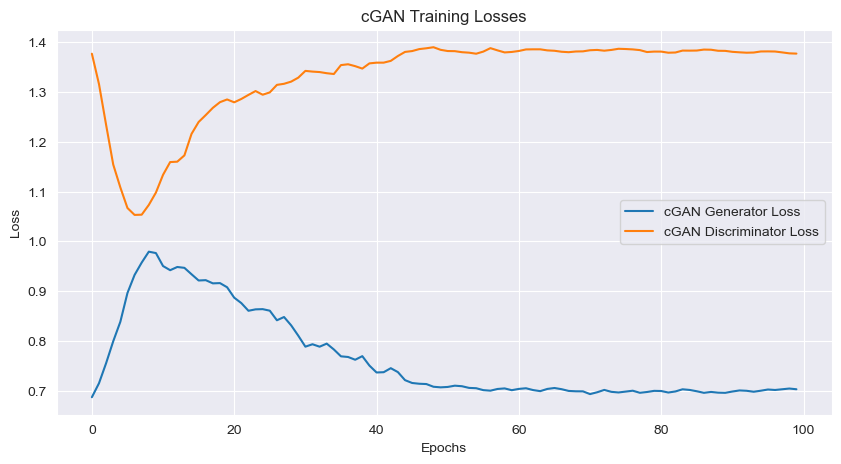

C:\Users\forgedRice\AppData\Local\Temp\ipykernel_72104\3059184799.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cgan_generator.load_state_dict(torch.load('best_cgan_g

CDiscriminator(
  (model): Sequential(
    (0): Linear(in_features=107, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [12]:
# cGAN Training Hyperparameters
CGAN_EPOCHS = 100
BATCH_SIZE = 128
LR_G = 0.00002
LR_D = 0.00001
LATENT_DIM = 64
BETA1 = 0.5
BETA2 = 0.999

# cGAN Training
print(f"\n--- cGAN Training---")
cgan_generator = CGenerator(LATENT_DIM, n_categories_per_feature_list, 256, 512).to(DEVICE)
cgan_discriminator = CDiscriminator(current_input_dim, 256, 128).to(DEVICE)

# DataLoader for cGAN
y_train_tensor_cgan_cond = torch.LongTensor(y_train).to(DEVICE)
cgan_train_dataset = TensorDataset(X_train_tensor, y_train_tensor_cgan_cond)
cgan_train_loader = DataLoader(cgan_train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

cgan_g_losses, cgan_d_losses = train_cgan(cgan_generator, cgan_discriminator, cgan_train_loader, LATENT_DIM,
                                          CGAN_EPOCHS, LR_G, LR_D, BETA1, BETA2, DEVICE)
plot_losses(cgan_g_losses, cgan_d_losses, "cGAN")

# Load best models
cgan_generator.load_state_dict(torch.load('best_cgan_g_model.pt', map_location=DEVICE))
cgan_discriminator.load_state_dict(torch.load('best_cgan_d_model.pt', map_location=DEVICE))
cgan_generator.to(DEVICE)
cgan_discriminator.to(DEVICE)

In [13]:
def generate_synthetic_data_cgan(generator, n_samples, latent_dim, y_train_for_ratios, num_classes, device):
    generator.eval()
    synthetic_data_list = []
    synthetic_labels_list = []

    unique_labels_train, counts_train = np.unique(y_train_for_ratios, return_counts=True)
    label_proportions = {label: count / len(y_train_for_ratios) for label, count in
                         zip(unique_labels_train, counts_train)}

    with torch.no_grad():
        current_total_samples = 0
        for label_idx in range(num_classes):
            proportion = label_proportions.get(label_idx, 0)
            num_samples_for_label = int(np.round(proportion * n_samples))

            if num_samples_for_label == 0:  # Skip if no samples for this label
                continue

            if label_idx == num_classes - 1:
                num_samples_for_label = n_samples - current_total_samples
                if num_samples_for_label <= 0 and n_samples > current_total_samples:
                    num_samples_for_label = n_samples - current_total_samples
                elif num_samples_for_label < 0:
                    num_samples_for_label = 0

            if num_samples_for_label <= 0:
                continue

            z_noise = torch.randn(num_samples_for_label, latent_dim).to(device)

            integer_labels_for_batch = torch.LongTensor([label_idx] * num_samples_for_label).to(device)

            cond_labels_one_hot = F.one_hot(integer_labels_for_batch, num_classes=num_classes).float().to(device)

            generated_batch = generator(z_noise, cond_labels_one_hot).cpu().numpy()
            synthetic_data_list.append(generated_batch)

            synthetic_labels_list.append(integer_labels_for_batch.cpu().numpy())
            current_total_samples += num_samples_for_label

    synthetic_data_cgan = np.concatenate(synthetic_data_list, axis=0)
    synthetic_labels_cgan = np.concatenate(synthetic_labels_list, axis=0)

    # Shuffle the cGAN generated data and labels together
    shuffle_indices = np.random.permutation(len(synthetic_data_cgan))
    synthetic_data_cgan = synthetic_data_cgan[shuffle_indices]
    synthetic_labels_cgan = synthetic_labels_cgan[shuffle_indices]

    generator.train()
    return synthetic_data_cgan, synthetic_labels_cgan

In [14]:
synthetic_data_cgan, synthetic_labels_cgan = generate_synthetic_data_cgan(cgan_generator, n_synthetic_samples,
                                                                          LATENT_DIM, y_train, len(target_class_names),
                                                                          DEVICE)
print(
    f"Generated {synthetic_data_cgan.shape[0]} cGAN samples with {len(np.unique(synthetic_labels_cgan))} unique labels.")

det_auc_rf_cgan, det_auc_lr_cgan = calculate_detection_metric(X_train_processed, synthetic_data_cgan, K_FOLDS_DETECTION,
                                                              SEED_BASE)
print(f"cGAN Detection Metric Random Forest (Avg AUC): {det_auc_rf_cgan:.4f} (Lower is better)")
print(f"cGAN Detection Metric Logistic Regression (Avg AUC): {det_auc_lr_cgan:.4f} (Lower is better)")

auc_real_cgan, auc_synth_cgan, eff_cgan = calculate_efficacy_metric(
    X_train_processed, y_train, X_test_processed, y_test,
    synthetic_data_cgan, synthetic_labels_cgan,  # cGAN synthetic data and its generated labels
    SEED_BASE
)
print(
    f"cGAN Efficacy: AUC_real={auc_real_cgan:.4f}, AUC_synthetic_cGAN={auc_synth_cgan:.4f}, Efficacy_cGAN={eff_cgan:.4f} (Higher is better)")

Generated 26048 cGAN samples with 2 unique labels.


C:\Users\forgedRice\anaconda3\envs\DRL\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\forgedRice\anaconda3\envs\DRL\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

cGAN Detection Metric Random Forest (Avg AUC): 1.0000 (Lower is better)
cGAN Detection Metric Logistic Regression (Avg AUC): 0.6699 (Lower is better)
cGAN Efficacy: AUC_real=0.8862, AUC_synthetic_cGAN=0.7903, Efficacy_cGAN=0.8918 (Higher is better)


C:\Users\forgedRice\anaconda3\envs\DRL\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


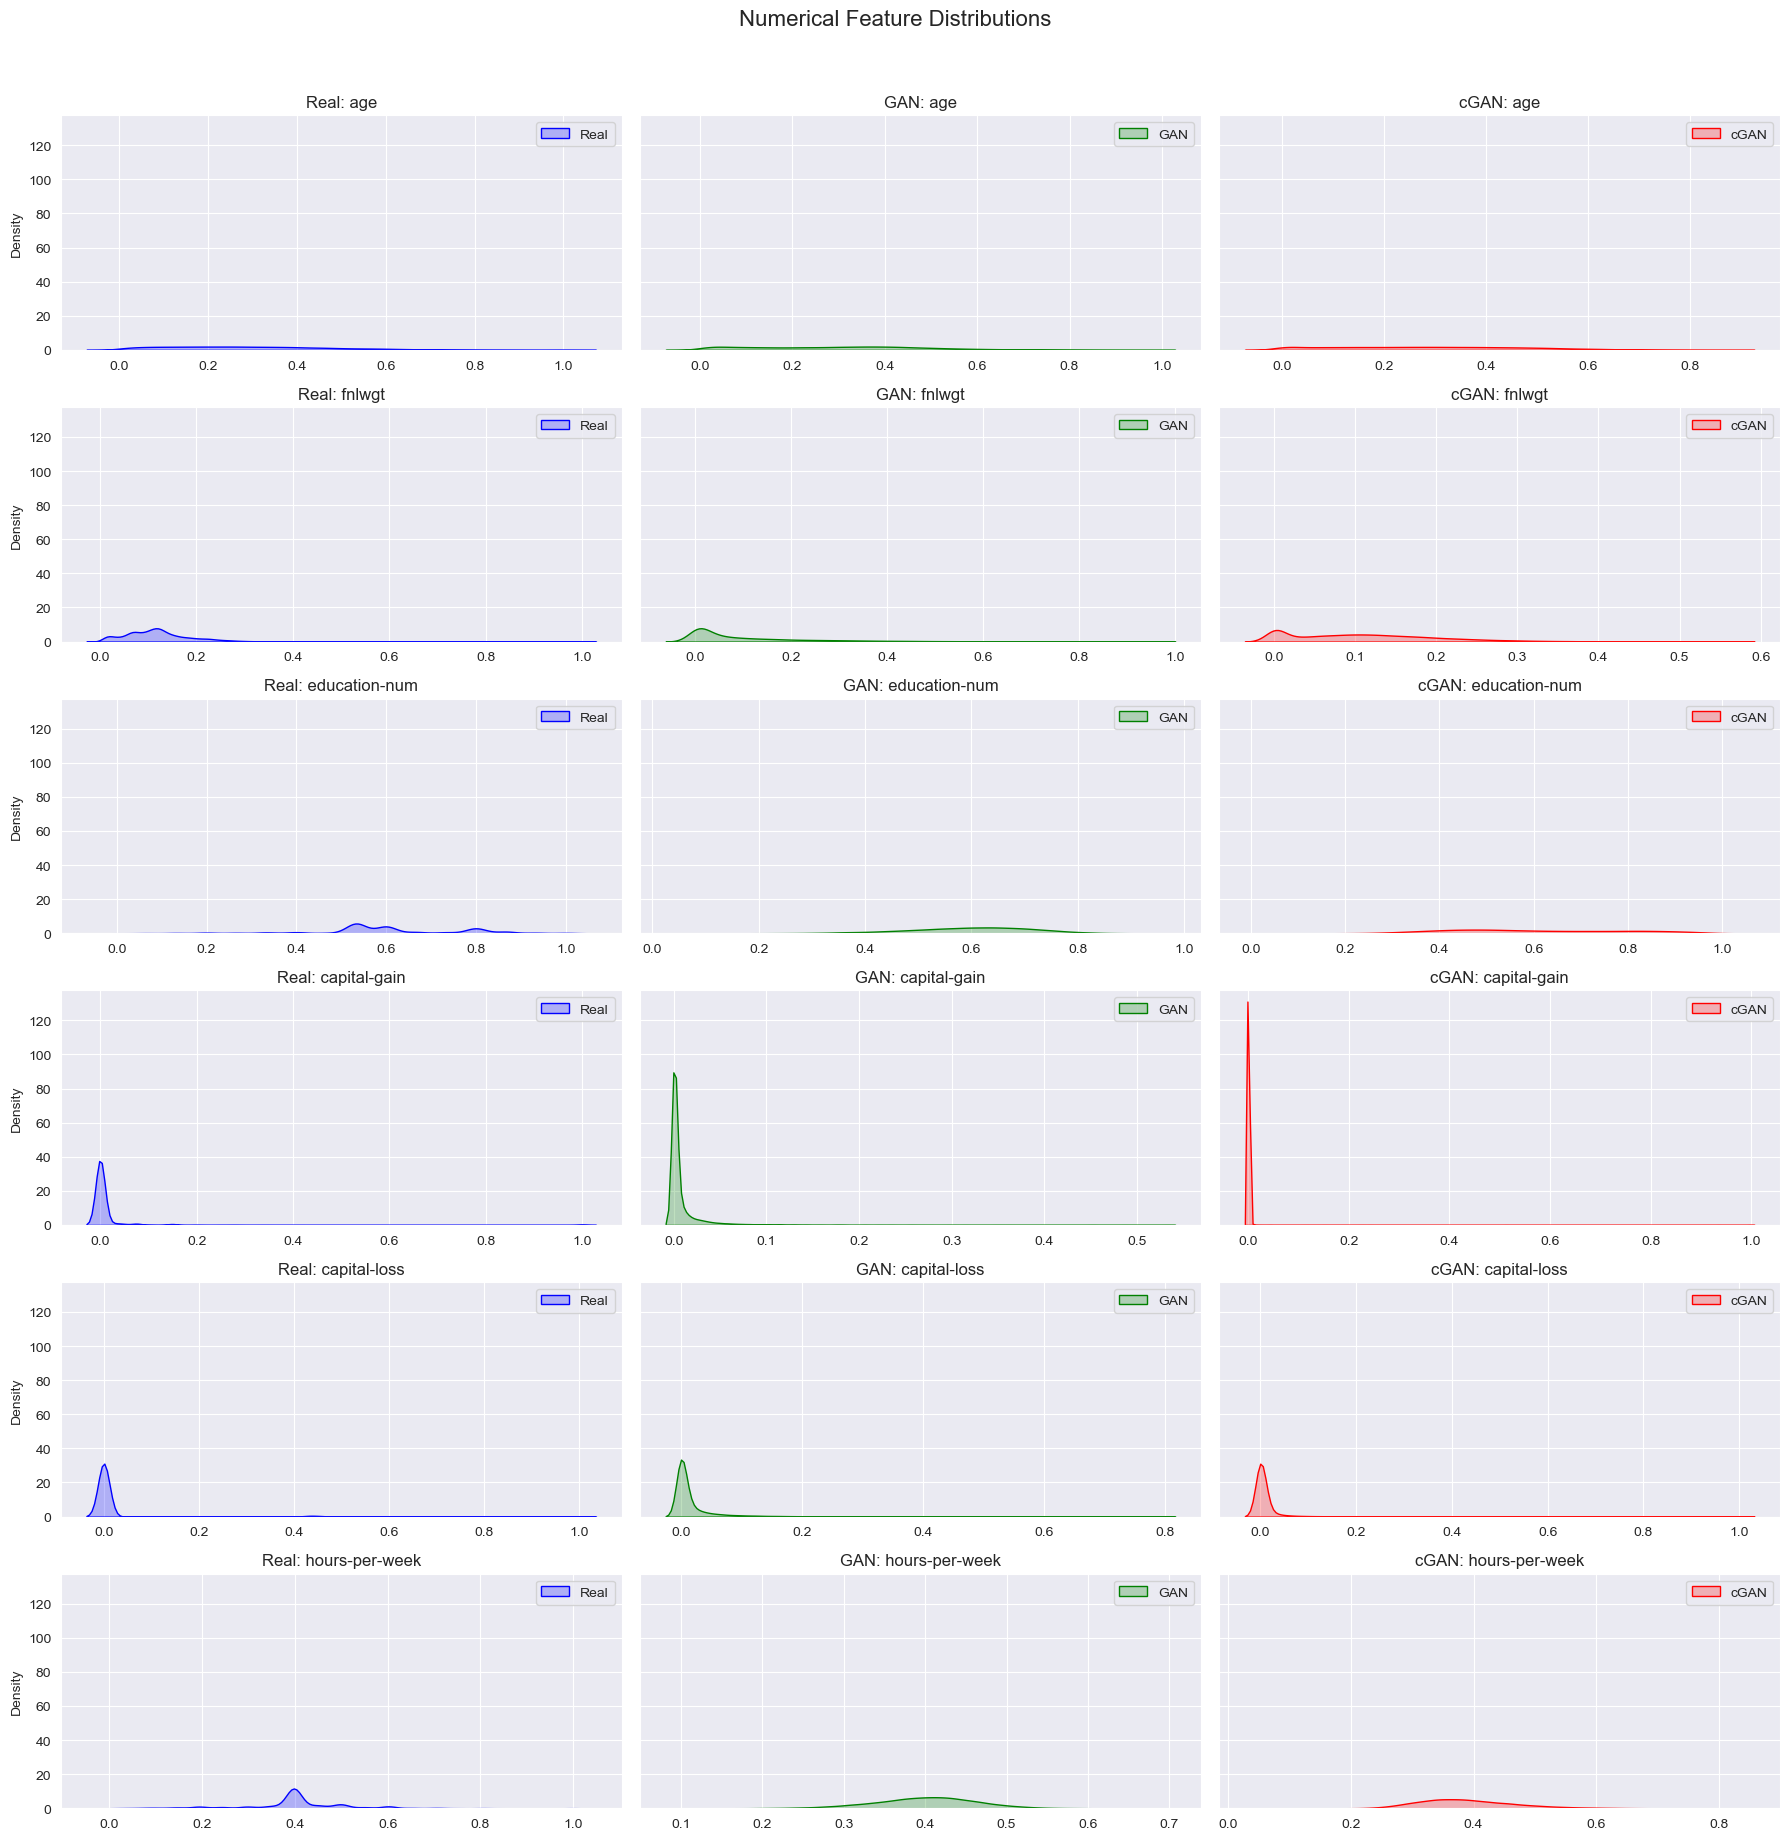

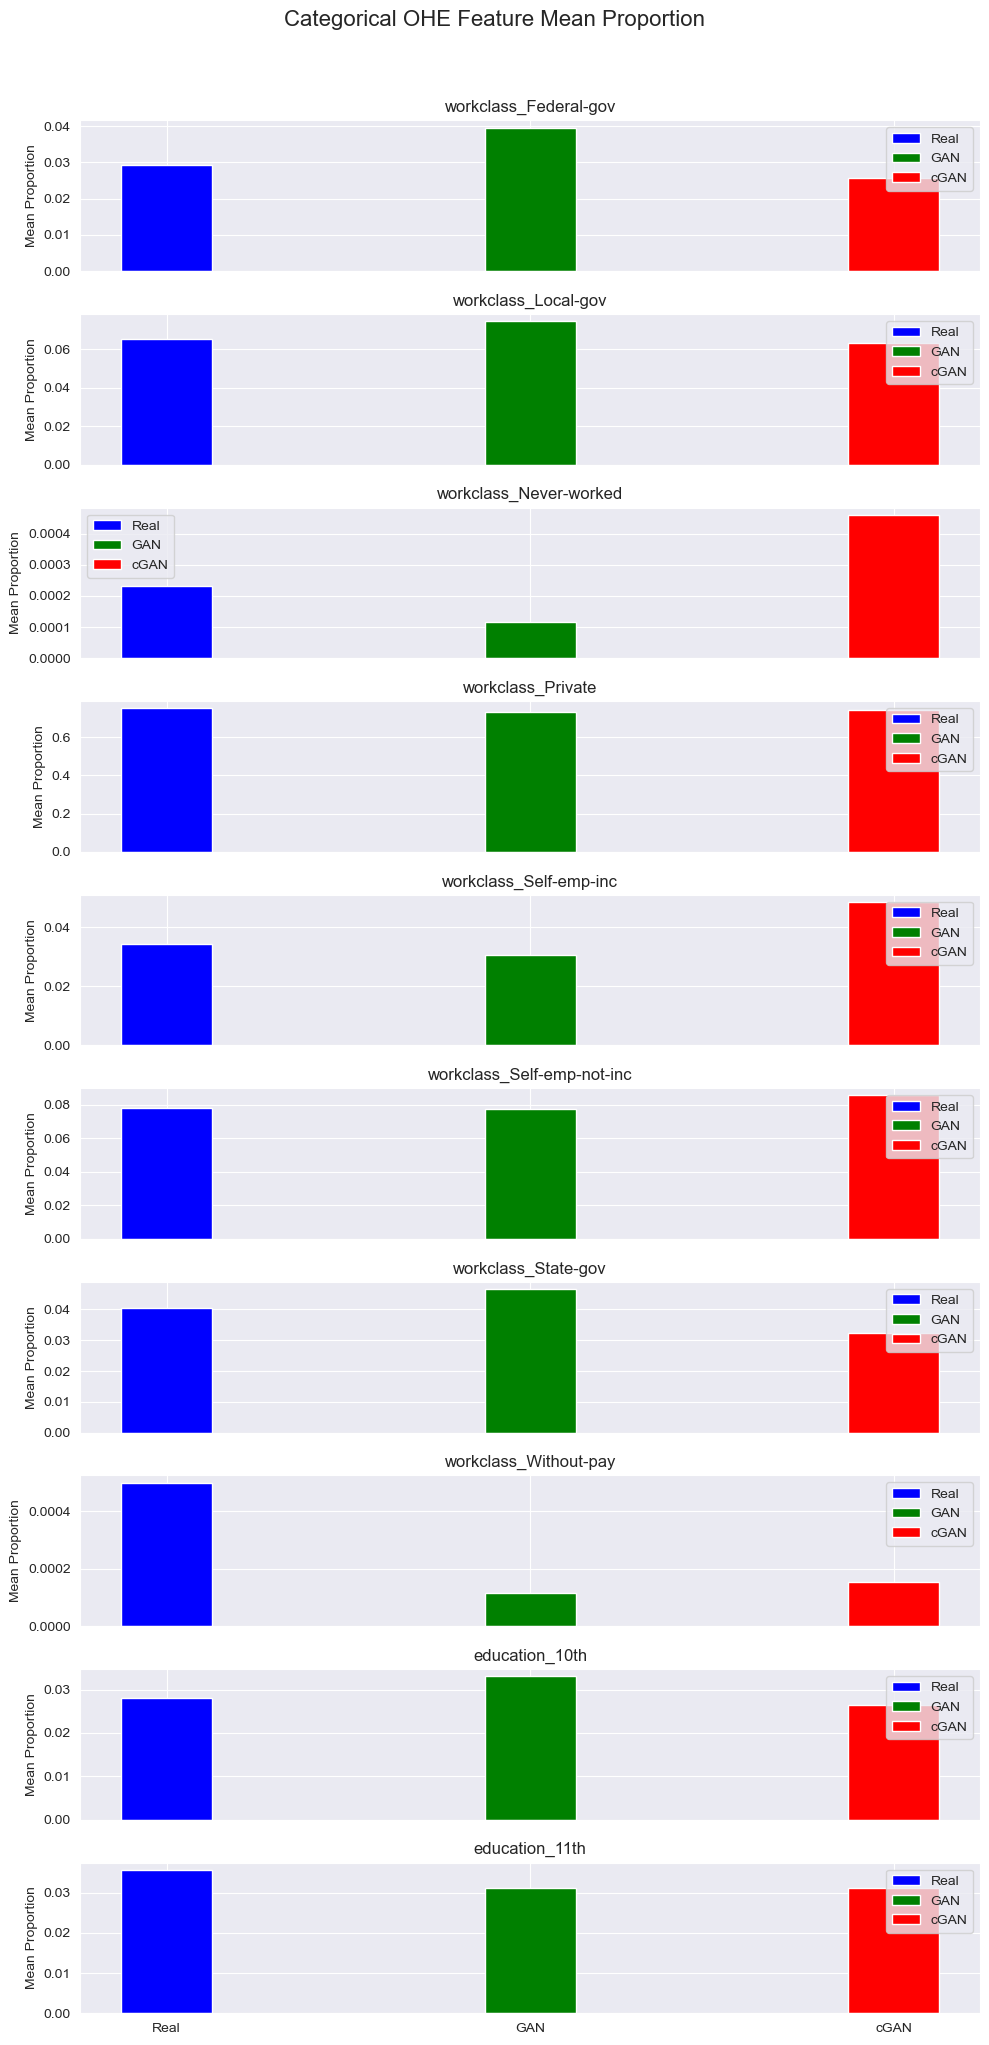

In [15]:
def plot_feature_distributions(real_data, synthetic_data_gan, synthetic_data_cgan,
                               feature_names, numerical_feat_indices, ohe_feat_indices,
                               num_features_to_plot=5):
    # Numerical Features - Histograms
    if numerical_feat_indices and num_features_to_plot > 0:
        plot_count_num = min(num_features_to_plot, len(numerical_feat_indices))
        fig, axes = plt.subplots(plot_count_num, 3, figsize=(18, 3 * plot_count_num), sharey=True)
        if plot_count_num == 1: axes = np.array([axes])  # Ensure axes is 2D

        fig.suptitle(f'Numerical Feature Distributions', fontsize=16, y=1.02)
        for i in range(plot_count_num):
            feat_idx = numerical_feat_indices[i]
            feat_name = feature_names[feat_idx]

            sns.kdeplot(real_data[:, feat_idx], ax=axes[i, 0], color='blue', label='Real', fill=True)
            axes[i, 0].set_title(f'Real: {feat_name}')
            axes[i, 0].legend()

            sns.kdeplot(synthetic_data_gan[:, feat_idx], ax=axes[i, 1], color='green', label='GAN', fill=True)
            axes[i, 1].set_title(f'GAN: {feat_name}')
            axes[i, 1].legend()

            sns.kdeplot(synthetic_data_cgan[:, feat_idx], ax=axes[i, 2], color='red', label='cGAN', fill=True)
            axes[i, 2].set_title(f'cGAN: {feat_name}')
            axes[i, 2].legend()
        plt.tight_layout()
        plt.show()

    # Categorical Features - Bar Plots
    if ohe_feat_indices and num_features_to_plot > 0:
        plot_count_cat = min(num_features_to_plot, len(ohe_feat_indices))
        fig, axes = plt.subplots(plot_count_cat, 1, figsize=(10, 2 * plot_count_cat), sharex=True)
        if plot_count_cat == 1: axes = np.array([axes])

        fig.suptitle(f'Categorical OHE Feature Mean Proportion', fontsize=16, y=1.02)
        width = 0.25  # width of the bars
        for i in range(plot_count_cat):
            feat_idx = ohe_feat_indices[i]
            feat_name = feature_names[feat_idx]

            means = [
                real_data[:, feat_idx].mean(),
                synthetic_data_gan[:, feat_idx].mean(),
                synthetic_data_cgan[:, feat_idx].mean()
            ]
            labels = ['Real', 'GAN', 'cGAN']
            colors = ['blue', 'green', 'red']

            x_pos = np.arange(len(labels))
            axes[i].bar(x_pos, means, width, color=colors, label=labels)
            axes[i].set_ylabel('Mean Proportion')
            axes[i].set_title(f'{feat_name}')
            axes[i].set_xticks(x_pos)
            axes[i].set_xticklabels(labels)
            axes[i].legend()

        plt.tight_layout()
        plt.show()


num_feat_indices_proc = [current_processed_feature_names.index(f) for f in NUMERICAL_FEATURES]
ohe_feat_indices_proc = [current_processed_feature_names.index(f) for f in current_ohe_names]

plot_feature_distributions(
    X_train_processed, synthetic_data_gan, synthetic_data_cgan,
    current_processed_feature_names, num_feat_indices_proc, ohe_feat_indices_proc,
    num_features_to_plot=10
)

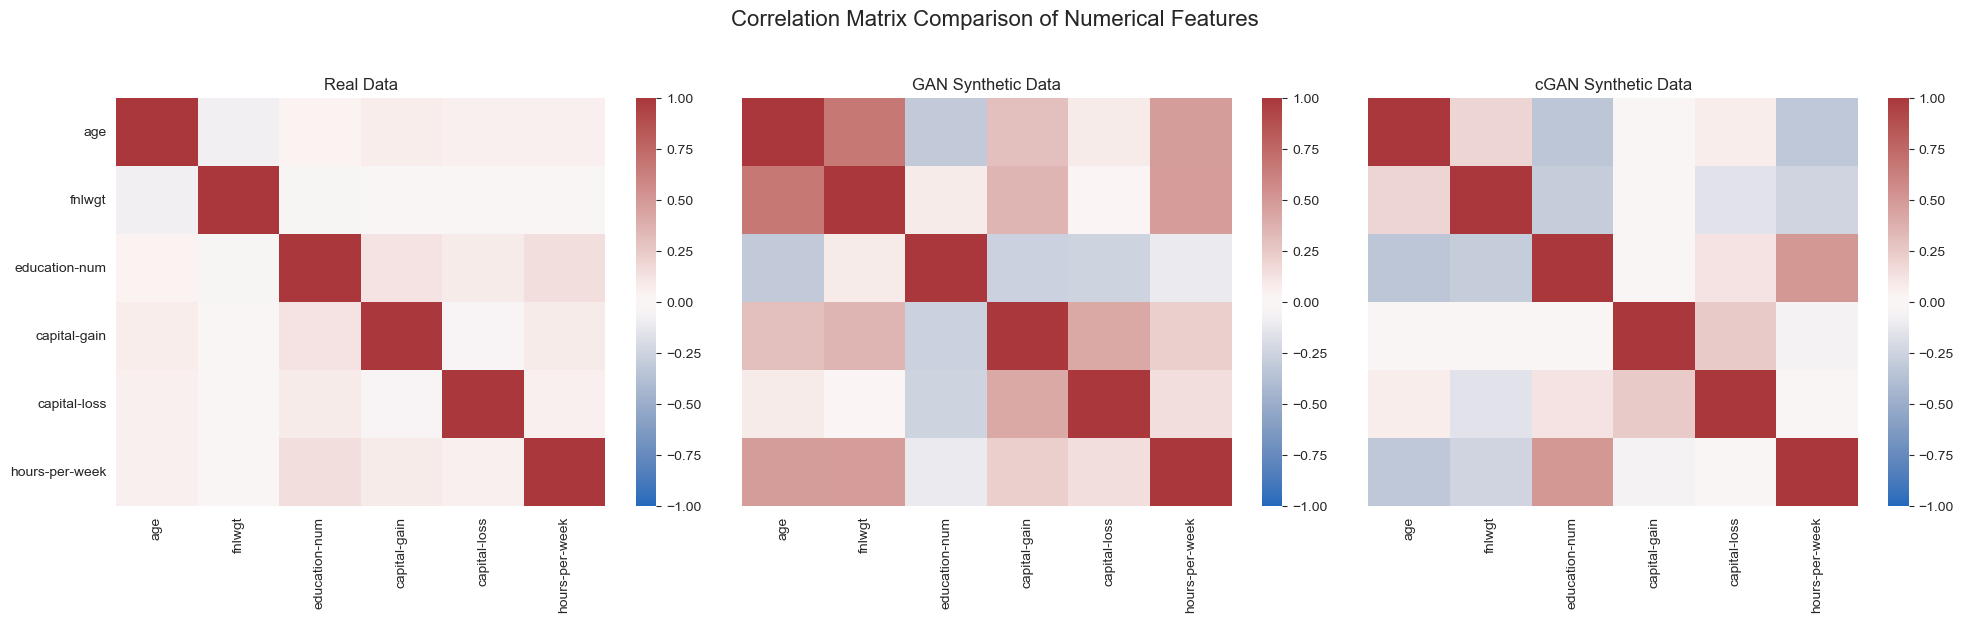

In [16]:
def plot_correlation_matrices(real_data, gan_data, cgan_data, feature_names):
    # Convert numpy arrays to pandas DataFrames
    df_real = pd.DataFrame(real_data, columns=feature_names)
    df_gan = pd.DataFrame(gan_data, columns=feature_names)
    df_cgan = pd.DataFrame(cgan_data, columns=feature_names)

    # Calculate correlation matrices
    corr_real = df_real.corr()
    corr_gan = df_gan.corr()
    corr_cgan = df_cgan.corr()

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Correlation Matrix Comparison of Numerical Features', fontsize=16, y=1.03)

    # Real Data Heatmap
    sns.heatmap(corr_real, ax=axes[0], cmap='vlag', vmin=-1, vmax=1)
    axes[0].set_title('Real Data')

    # GAN Data Heatmap
    sns.heatmap(corr_gan, ax=axes[1], cmap='vlag', vmin=-1, vmax=1)
    axes[1].set_title('GAN Synthetic Data')
    axes[1].set_yticks([])

    # cGAN Data Heatmap
    sns.heatmap(corr_cgan, ax=axes[2], cmap='vlag', vmin=-1, vmax=1)
    axes[2].set_title('cGAN Synthetic Data')
    axes[2].set_yticks([])

    plt.tight_layout()
    plt.show()

# Extract only the numerical feature columns for correlation analysis
real_numerical_data = X_train_processed[:, :len(NUMERICAL_FEATURES)]
gan_numerical_data = synthetic_data_gan[:, :len(NUMERICAL_FEATURES)]
cgan_numerical_data = synthetic_data_cgan[:, :len(NUMERICAL_FEATURES)]

plot_correlation_matrices(real_numerical_data, gan_numerical_data, cgan_numerical_data, NUMERICAL_FEATURES)